# Predicción de Suscripción a un Depósito Bancario

- Manuel Manchado Barquero (NIA: 100522228)
- David Mateu Serrano (NIA: 100522337)

[Repositorio Github](https://github.com/100522228/P1_Machine_learning.git)

## EDA
En esta sección realizamos un análisis técnico de los datos para determinar la estrategia de preprocesamiento. El objetivo es identificar la naturaleza de las variables y posibles problemas en el dataset.

In [34]:
import pandas as pd
from IPython.display import display
import numpy as np
from pathlib import Path

# Establecemos la semilla para permitir reproducir los resultados
SEED = 100522228
target = 'deposit' # Dejamos creada la variable que se usará más adelante

# Leemos los datos
file_path = Path("content/P1") / "bank_10.pkl"
df = pd.read_pickle(file_path)

# Identificamos el número de instancias y variables
n_instancias, n_variables = df.shape
print(f"El dataset contiene {n_instancias} instancias y {n_variables} variables.")
# Ya que deposit solo contiene los valores si o no, nos encontramos ante un problema de clasificación binaria
print(f"Tipo de problema: Clasificación binaria (Target: '{target}')")

# Vamos a recorrer todas las variables para sacar la información necesaria de cada una
# Listas para clasificar los distintos tipos de datos (las ordinales las introducimos por conocimiento propio, ya que no se pueden distinguir a simple vista de las categóricas)
var_ordinales = ['education', 'month']
var_numericas = []
var_categoricas = []

for col in df.columns:
    if col == target:
        continue
    # Vamos clasificando las variables que nos quedan (numéricas y categóricas)
    if np.issubdtype(df[col].dtype, np.number):
        var_numericas.append(col)
    elif col in var_ordinales:
        continue # Ya está en la lista de ordinales
    else:
        var_categoricas.append(col)

# Una vez que tenemos los tipos de las variables, identificamos la alta cardinalidad (solamente para variables categóricas), las ctes y los ID
alta_cardinalidad = []
columnas_constantes = []
columnas_id = []

# Mostramos los resultados a modo de tabla
print(f"\n{'COLUMNA':<15} | {'TIPO':<10} | {'ÚNICOS':<7} | {'NaN (%)':<12} | {'UNKNOWN (%)':<12}")
print("-" * 75)

for col in df.columns:
    # Además, identificamos los valores únicos (solo para los categóricos), los Nan y los unknown
    n_nan = df[col].isna().sum()
    n_unknown = (df[col] == 'unknown').sum() if df[col].dtype == 'object' else 0
    n_unicos = df[col].nunique()

    # Calculamos porcentajes
    pct_nan = (n_nan / n_instancias) * 100
    pct_unknown = (n_unknown / n_instancias) * 100
    
    # Preparamos los strings de visualización
    nan_display = f"{n_nan} ({pct_nan:.1f}%)"
    unknown_display = f"{n_unknown} ({pct_unknown:.1f}%)"

    
    # Determinamos la etiqueta del tipo
    if col == target:
        tipo_str = "TARGET"
        unicos_display = str(n_unicos)
    elif col in var_numericas:
        tipo_str = "Numérica"
        unicos_display = "-" # No tiene sentido mostrar los valores únicos de una variable numérica
    elif col in var_ordinales:
        tipo_str = "Ordinal"
        unicos_display = str(n_unicos)
        if n_unicos > 10:
            alta_cardinalidad.append(col)
    else:
        tipo_str = "Categórica"
        unicos_display = str(n_unicos)
        if n_unicos > 10:
            alta_cardinalidad.append(col)

   # Imprimimos la información con el nuevo formato
    print(f"{col:<15} | {tipo_str:<10} | {unicos_display:<7} | {nan_display:<12} | {unknown_display:<12}")

    # Comprobaciones de integridad (ctes o ID)
    if col != target:
        if n_unicos <= 1:
            columnas_constantes.append(col)
        if n_unicos == n_instancias:
            columnas_id.append(col)

print("-" * 65)

# Imprimimos los resultados adicionales
print(f"\nVariables con alta cardinalidad (>10): {alta_cardinalidad}")
print(f"Columnas constantes: {columnas_constantes}")
print(f"Columnas tipo ID: {columnas_id}")


# Ahora comprobamos el balanceo de deposit. Nuestro objetivo es identificar un posible desbalanceo
counts = df[target].value_counts()
percentages = df[target].value_counts(normalize=True) * 100

print(f"\nBalanceo de la clase '{target}':")
for index in counts.index:
    print(f"{index}: {counts[index]} ({percentages[index]:.2f}%)")

# Pdays (estadísticas)
n_minus_one = (df['pdays'] == -1).sum()
print(f"\nAnálisis de 'pdays': {n_minus_one} instancias con -1 ({n_minus_one/n_instancias:.2%})")

El dataset contiene 11000 instancias y 17 variables.
Tipo de problema: Clasificación binaria (Target: 'deposit')

COLUMNA         | TIPO       | ÚNICOS  | NaN (%)      | UNKNOWN (%) 
---------------------------------------------------------------------------
age             | Numérica   | -       | 0 (0.0%)     | 0 (0.0%)    
job             | Categórica | 12      | 332 (3.0%)   | 66 (0.6%)   
marital         | Categórica | 3       | 183 (1.7%)   | 0 (0.0%)    
education       | Ordinal    | 4       | 0 (0.0%)     | 494 (4.5%)  
default         | Categórica | 2       | 0 (0.0%)     | 0 (0.0%)    
balance         | Numérica   | -       | 0 (0.0%)     | 0 (0.0%)    
housing         | Categórica | 2       | 0 (0.0%)     | 0 (0.0%)    
loan            | Categórica | 2       | 0 (0.0%)     | 0 (0.0%)    
contact         | Categórica | 3       | 0 (0.0%)     | 2309 (21.0%)
day             | Numérica   | -       | 0 (0.0%)     | 0 (0.0%)    
month           | Ordinal    | 12      | 0 (0.0%)  

En cuanto a la calidad y el tipo de variables, no se han encontrado columnas que sean constantes ni identificadores únicos. Aun así, hay que tener en cuenta que algunas variables, como `job` y `month`, tienen una cardinalidad alta (más de 10 valores distintos), pero sin llegar a ser nada extremo. Además, tenemos variables con una alta cantidad de 'unknown' como `poutcome` y `contact` 

En lo que respecta a la variable objetivo, los datos están bastante equilibrados: aproximadamente un 52,55% corresponden a la clase "no" y un 47,45% a la clase "yes".

Por otro lado, la variable `pdays` tiene una característica importante: cerca del 74,57% de los registros tienen el valor -1. Es clave tratar este detalle mediante el preprocesado, el cual, no se basa en cálculos globales como medias o modas, sino en el propio significado de los datos, por ello, no hay riesgo de introducir *data leakage*. Sin embargo, a pesar de no suponer un *data leakage* vamos a introducirlo más adelante en el pipeline para que su tratamiento se realice automáticamente en el modelo final.

## Definición evaluación

Para la evaluación externa usaremos un Holdout dividiendo los datos en 2/3 para entrenamiento y 1/3 para test. Dado que las clases de la variable deposit están balanceadas, el Accuracy es una métrica robusta para medir el rendimiento real. 

In [35]:
from sklearn.model_selection import train_test_split

# Convertimos el target a numérico: 'yes' -> 1, 'no' -> 0 (si no hacemos esto, al usar Optuna nos dará error)
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

# Definimos X (predictores) e y (objetivo) 
X = df.drop(columns=[target])
y = df[target]

# Realizamos el split 1/3 para test y 2/3 para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.33, 
    random_state=SEED, 
    stratify=y # Mantiene la proporción de la clase 'deposit'
)


## Métodos básicos: KNN y Trees

### Elección método de escalado

Antes de evaluar los modelos, es fundamental determinar el método de escalado óptimo (**Standard**, **MinMax** o **Robust**) utilizando `KNN` como referencia y validación cruzada (3-fold CV). Todo el preprocesamiento se integra en *Pipelines* para evitar data leakage.

Se ha realizado un mapeo de las variables categóricas binarias (las cuales tenían los valores 'yes' y 'no') para que pasasen a ser variables binarias numéricas (0 o 1). Con esto, evitamos usar el One-Hot-Encoding en este caso, lo que ahorra la creación de variables auxiliares.

Respecto a `pdays`, se ha creado una nueva variable llamada `pdays_contacted`, que indica si el cliente ha sido contactado antes, vale 1 si sí lo ha sido, y 0 en caso de no contacto o en caso desconocido. Esto ayuda al modelo a captar rápidamente si existe ese historial previo sin tener que recurrir a `pdays`. Además, en la variable original `pdays`, se han sustituido los valores -1 por 0. Así, la variable pasa a tener únicamente valores numéricos coherentes, representando el tiempo desde el último contacto. Con esto evitamos problemas donde un -1 podría interpretarse como un valor menor que 0 días y afectar a los resultados.

Para las variables numéricas, se emplea la imputación por mediana para mitigar el impacto de los valores atípicos. Las variables ordinales se gestionan con un **Ordinal Encoder** e imputación por moda debido a su baja tasa de ausencia. En cuanto a las categóricas (sin contar a las binarias), se aplica **One-Hot Encoding** e imputación por moda en columnas con pocos valores faltantes; sin embargo, en aquellas con alta presencia de "unknown" o NaN, estos se tratan como una categoría informativa independiente.

Esta estrategia permite transformar la ausencia de datos en una fuente de información útil. Partimos de la premisa de que si un cliente no especifica un dato, ese silencio constituye un comportamiento con valor predictivo propio, ya sea un NaN, o un 'unknown' para nosotros, significará lo mismo.

In [62]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier

# Variables binarias (default, housing, loan) -> codificación 0 o 1
var_binarias = ['default', 'housing', 'loan']

# Categóricas con muchos Unknown -> tratamos 'unknown' como una clase más
var_cat_unknown = ['contact', 'poutcome'] 

# Categóricas normales -> One-Hot + Imputación moda
var_cat_moda = [col for col in var_categoricas if col not in var_cat_unknown + var_binarias]

# Ordinales -> Orden específico definido en las listas
var_ordinales = ['education', 'month']
educ_order = ['primary', 'secondary', 'tertiary']
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Definimos los transformadores
# Transformador de pdays, al crear pdays_contacted, no queremos transformarla más ya que ya tiene valores 0/1
def pdays_feature_engineering(X):
    X = X.copy()
    # Crear variable binaria: si fue contactado anteriormente
    X['pdays_contacted'] = (X['pdays'] != -1).astype(int)
    # Reemplazar -1 por 0
    X['pdays'] = X['pdays'].replace(-1, 0)
    return X

pdays_transformer = FunctionTransformer(
    pdays_feature_engineering,
    validate=False
)

# Categóricas con Unknown como clase
cat_unknown_transformer = Pipeline(steps=[
    # Aquí, si se encuentra con un NaN, lo transforma a unknown
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Categóricas con Moda + OneHot
cat_moda_transformer = Pipeline(steps=[
    # Hacemos que se encuentre con un NaN o con un unknown, se remplace por la moda
    ('replace_unk', SimpleImputer(missing_values='unknown', strategy='most_frequent')),
    ('imputer_nan', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Binarias: yes/no -> 1/0
bin_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('binary', OrdinalEncoder(
    categories=[['no', 'yes'] for _ in var_binarias],
    dtype=int))
])

# Definimos una función que crea el preprocesador pasándole como parámetro el método de escalado
def create_preprocessor(scaler):
    return Pipeline(steps=[
        ('pdays_feat', pdays_transformer), # Primero modificamos pdays, y luego el resto de transformadores
        ('column_transform', ColumnTransformer(transformers=[
            # Solamente aplicamos el escalado a las variables numéricas y a las ordinales, el resto al ser binarias o One-Hot-Encoding, no tiene snetido aplicar un escalado
            ('num', Pipeline(steps=[('imp', SimpleImputer(strategy='median')), ('sc', scaler)]), var_numericas),
            ('cat_unk', cat_unknown_transformer, var_cat_unknown),
            ('cat_moda', cat_moda_transformer, var_cat_moda),
            ('ord', Pipeline(steps=[
                ('replace_unk', SimpleImputer(missing_values='unknown', strategy='most_frequent')),
                ('ordinal', OrdinalEncoder(categories=[educ_order, month_order])),
                ('sc', scaler)
            ]), var_ordinales),
            ('bin', bin_transformer,var_binarias),
        ],
        remainder='passthrough' # Indicamos que no queremos que pdays_contacted se transforme
        ))
    ])

# Definimos los escaladores que vamos a probar
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

cv_inner = KFold(n_splits=3, shuffle=True, random_state=SEED) 
results = {}

print(f"{'Escalador':<20} | {'Accuracy':<15}")
print("-" * 40)

# Vamos probándolos uno a uno en este bucle y vamos comparando sus accuracy.
for name, scaler_obj in scalers.items():
    prep = create_preprocessor(scaler_obj)
    
    pipeline = Pipeline(steps=[
        ('pre', prep),
        ('knn', KNeighborsClassifier())
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv_inner, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name:<20} | {scores.mean():.4f}")

# Mostramos el resultado
best_scaler_name = max(results, key=results.get)
print(f"\nEl mejor método de escalado para KNN es: {best_scaler_name}")

Escalador            | Accuracy       
----------------------------------------
StandardScaler       | 0.7893
MinMaxScaler         | 0.7000
RobustScaler         | 0.7828

El mejor método de escalado para KNN es: StandardScaler


### Evaluación con HP por defecto

Tras seleccionar el escalador óptimo, procedemos a *evaluar el rendimiento base* de los modelos `KNN`y `Árbol de Decisión` utilizando sus hiperparámetros por defecto y midiendo el tiempo de entrenamiento. 

Para evitar el data leakage, integramos nuevamente el preprocesamiento dentro de los Pipelines, asegurando que tanto la imputación por mediana como el One-Hot Encoding se ajusten exclusivamente en el conjunto de entrenamiento de cada iteración. 

Cabe destacar que para simplificar, vamos a usar el preproceso creado anteriormente a lo largo de toda la práctica con los distintos modelos. En los árboles, no haría falta realizar el escalado, sin embargo, como no afecta negativamente hacerlo (simplemente da igual) vamos a llamar directamente al preproceso entero cada vez que vayamos a trabajar con nuevos modelos.

In [37]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# Recuperamos el mejor escalador de la etapa anterior
best_scaler_object = scalers[best_scaler_name] 
best_preprocessor = create_preprocessor(best_scaler_object)

# Creamos un diccionario vacío para almacenar los resultados (los usaremos luego en las conclusiones también)
resultados_defecto = {}

# Definimos los modelos con sus Pipelines
knn_pipeline = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', KNeighborsClassifier())
])

tree_pipeline = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', DecisionTreeClassifier(random_state=SEED))
])

modelos = {
    'KNN': knn_pipeline,
    'Árbol de Decisión': tree_pipeline
}

# Tabla
print(f"{'Modelo':<28} | {'Accuracy':<15} | {'Tiempo Train'}")
print("-" * 65)

# Evaluación y medición
for nombre, pipe in modelos.items():
    # Medimos el tiempo de entrenamiento (fit) sobre el conjunto X_train 
    inicio = time.time()
    pipe.fit(X_train, y_train)
    tiempo_train = time.time() - inicio
    
    # Calculamos el accuracy mediante CV
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='accuracy')
    mean_accuracy = scores.mean()
    
    # Guardamos los datos en el diccionario para uso posterior
    resultados_defecto[nombre] = {
        'accuracy': mean_accuracy,
        'tiempo': tiempo_train
    }
    
    # Imprimimos la fila
    print(f"{nombre:<28} | {mean_accuracy:.4f}          | {tiempo_train:.4f}s")

Modelo                       | Accuracy        | Tiempo Train
-----------------------------------------------------------------
KNN                          | 0.7893          | 0.0607s
Árbol de Decisión            | 0.7782          | 0.0921s


### Árbol de baja profundidad

A continuación, vamos a hacer uso de un árbol de decisión de baja profundidad (profundidad 3) para aprovechar su capacidad de visualización. Esto nos permitirá identificar de forma directa los atributos más relevantes y comprender las decisiones críticas que determinan la suscripción del cliente.

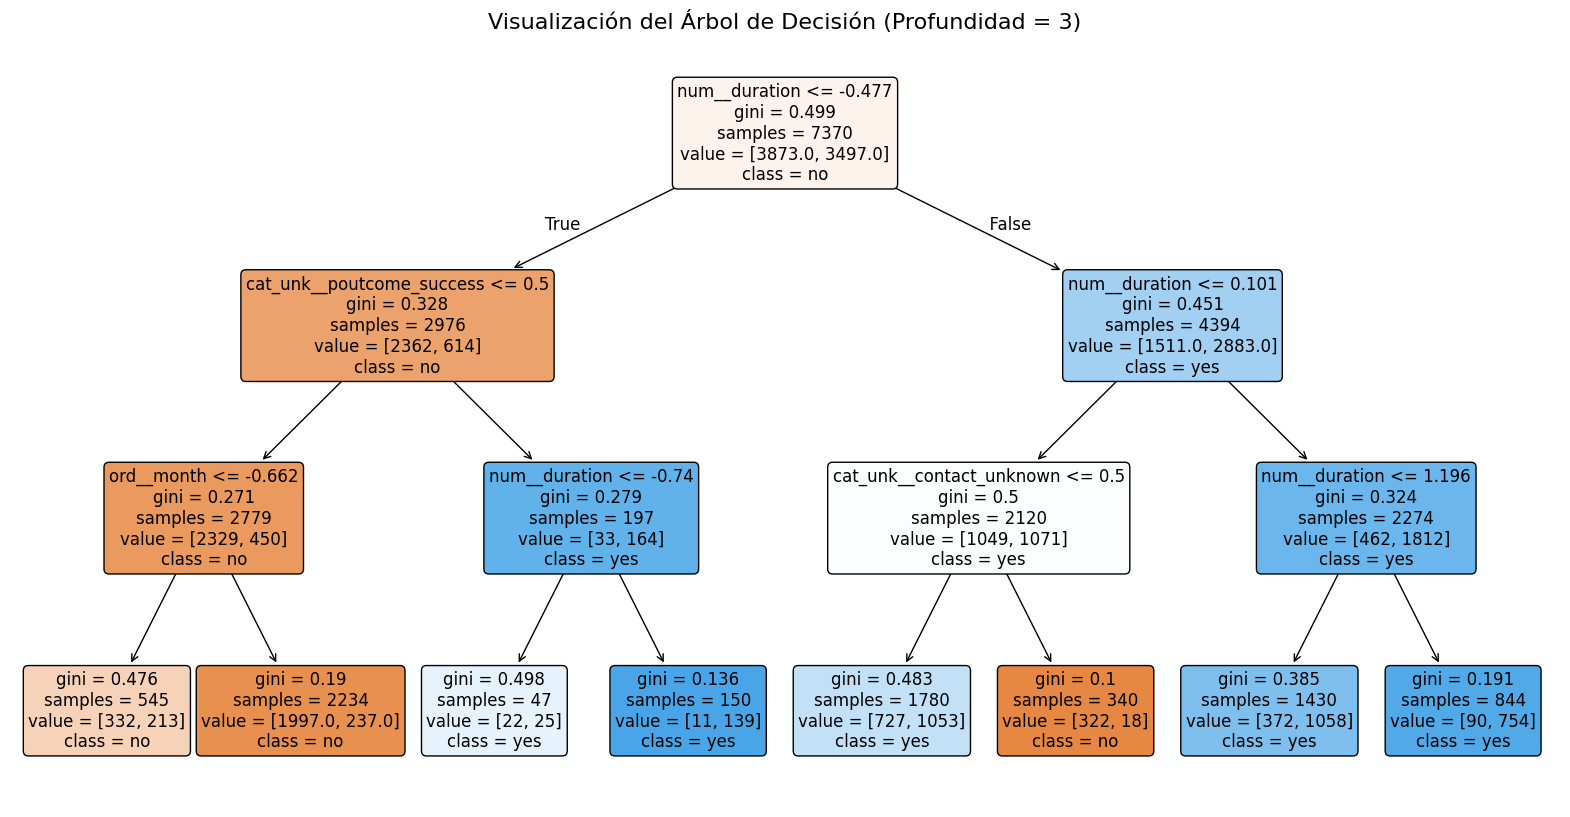

In [39]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Creamos un Pipeline específico para el árbol de poca profundidad
tree_interp_pipe = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])

# Hacemos fit con el conjunto X_train
tree_interp_pipe.fit(X_train, y_train)

# Visualización del árbol
plt.figure(figsize=(20, 10))
plot_tree(
    tree_interp_pipe.named_steps['model'],
    feature_names=tree_interp_pipe.named_steps['pre'].named_steps['column_transform'].get_feature_names_out(),
    class_names=['no', 'yes'],
    filled=True, 
    rounded=True, 
    fontsize=12
)
plt.title("Visualización del Árbol de Decisión (Profundidad = 3)", fontsize=16)
plt.show()

La estructura del árbol revela que la duración de la llamada (`num__duration`) es el factor determinante, situando el primer umbral crítico en el valor escalado de -0.477. Las llamadas que superan este tiempo derivan en una probabilidad de suscripción significativamente mayor, clasificándose inicialmente como 'yes' (rama derecha).

En un segundo nivel, el modelo prioriza el éxito en campañas anteriores (poutcome_success) y refinamientos adicionales de la duración. Se observa que un historial positivo de suscripción aumenta drásticamente las posibilidades de éxito actual, incluso cuando la llamada es breve. Por el contrario, si la duración es muy alta (nivel superior a 1.196), la predicción se inclina casi totalmente hacia el éxito.

En el tercer nivel, el modelo introduce la estacionalidad (`ord__month`) y el medio de contacto (cat_unk__contact_unknown) como criterios de desempate. En las llamadas cortas sin éxito previo, el mes de la campaña discrimina el 'no', mientras que en las llamadas largas, el desconocimiento del tipo de contacto separa los casos de éxito de aquellos con menor probabilidad de suscripción.

### Optimización (HPO)

Ahora es momento de realizar el ajuste de hiperparámetros. Para ello se va a usar Optuna, el cual es un método más eficiente que grid search o random search, ya que deja de explorar configuraciones mediocres y se centra en las prometedoras, consiguiendo mejores resultados en mucho menos tiempo. 

In [40]:
import optuna.integration
from optuna.distributions import IntDistribution as IntDist
from optuna.distributions import CategoricalDistribution as CatDist 
from sklearn import metrics

# Lo añadimos para limpar la salida y que no haya tanto texto
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Definimos los pipelines completos para que Optuna los procese internamente
pipe_knn = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', KNeighborsClassifier())
])

pipe_tree = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', DecisionTreeClassifier(random_state=SEED))
])

# Definimos los hiperparámetros que queremos optimizar de cada modelo.
param_grid_knn = {
    'model__n_neighbors': IntDist(1, 51, step=2),
    'model__weights': CatDist(['uniform', 'distance']),
    'model__p': IntDist(1, 2),
    'model__leaf_size': IntDist(20, 50)
}

param_grid_tree = {
    'model__max_depth': IntDist(2, 30),
    'model__min_samples_split': IntDist(2, 30),
    'model__min_samples_leaf': IntDist(1, 15), # Número minimo de samples para ser un nodo hoja
    'model__criterion': CatDist(['gini', 'entropy']),
}

budget = 50

# Comenzamos la optimización para KNN
optuna_knn = optuna.integration.OptunaSearchCV(
    pipe_knn,
    param_grid_knn,
    scoring='accuracy',  
    n_trials=budget,
    cv=cv_inner,
    n_jobs=-1, 
    verbose=1,
    timeout=600,
    random_state=SEED,
)

# Controlamos el tiempo
start_time = time.time()
optuna_knn.fit(X_train, y_train)
tiempo_knn = time.time() - start_time

# Comenzamos la optimización para el árbol
optuna_tree = optuna.integration.OptunaSearchCV(
    pipe_tree,
    param_grid_tree,
    scoring='accuracy',
    n_trials=budget,
    cv=cv_inner,
    n_jobs=-1, 
    verbose=1,
    timeout=600,
    random_state=SEED,
)

# Controlamos el tiempo
start_time = time.time()
optuna_tree.fit(X_train, y_train)
tiempo_tree = time.time() - start_time

# Creamos un diccionario con los resultados de ambos modelos
resultados = {
    "Modelo": ["K-Nearest Neighbors", "Decision Tree"],
    "Mejor Accuracy (CV)": [optuna_knn.best_score_, optuna_tree.best_score_],
    "Tiempo ejecución": [f"{tiempo_knn:.2f}s", f"{tiempo_tree:.2f}s"],
    "Mejores Parámetros": [optuna_knn.best_params_, optuna_tree.best_params_]
}

# Mostramos los resultados en forma de dataframe
pd.set_option('display.max_colwidth', None) # Esto permite que se lean todos los parámetros óptimos y que no salgan cortados
df_resumen = pd.DataFrame(resultados)
display(df_resumen.sort_values(by="Mejor Accuracy (CV)", ascending=False).reset_index(drop=True))

/tmp/ipykernel_89245/3328757585.py:38: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_knn = optuna.integration.OptunaSearchCV(
/tmp/ipykernel_89245/3328757585.py:56: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_tree = optuna.integration.OptunaSearchCV(


,Modelo,Mejor Accuracy (CV),Tiempo ejecución,Mejores Parámetros
0,Decision Tree,0.816009,13.74s,"{'model__max_depth': 13, 'model__min_samples_split': 13, 'model__min_samples_leaf': 14, 'model__criterion': 'entropy'}"
1,K-Nearest Neighbors,0.798371,16.70s,"{'model__n_neighbors': 17, 'model__weights': 'distance', 'model__p': 2, 'model__leaf_size': 23}"


A continuación se muestra el impacto de cada hiperparámetro probado en el rendimiento del modelo mediante plots.


Análisis de Hiperparámetros para K-Nearest Neighbors:


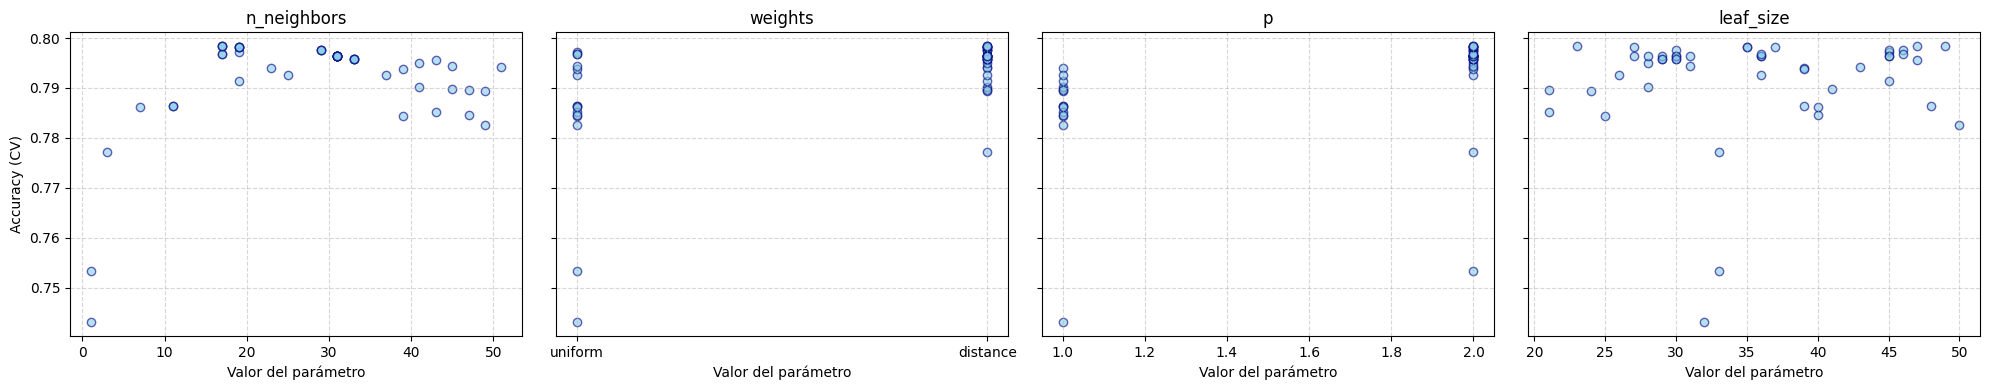


Análisis de Hiperparámetros para Decision Tree:


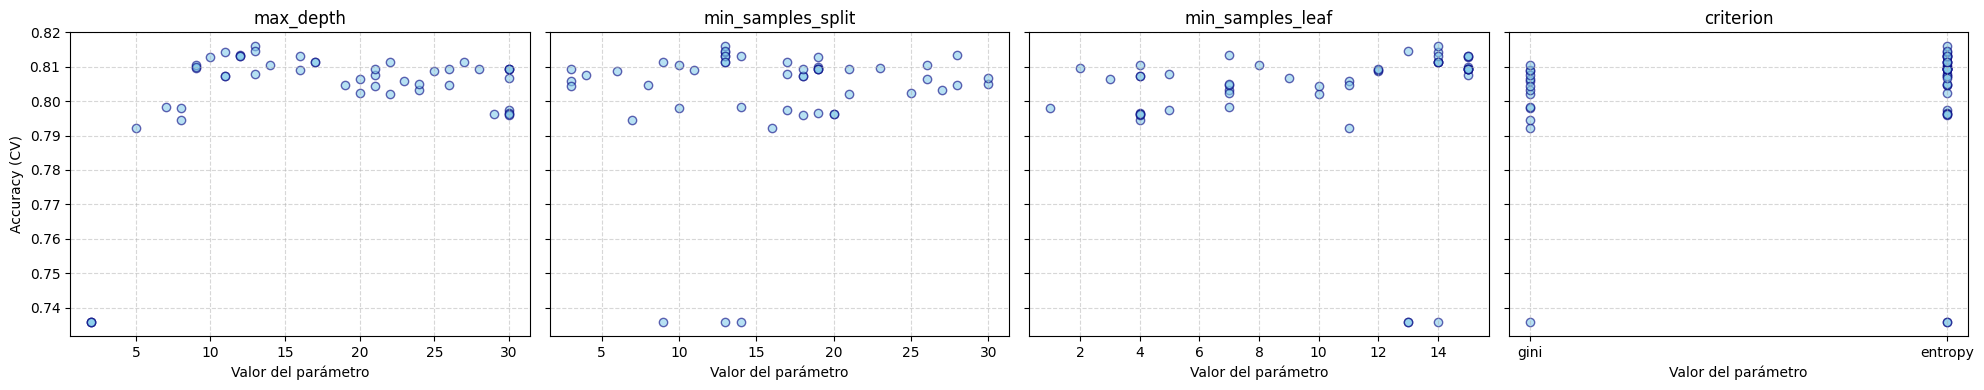

In [41]:
import matplotlib.pyplot as plt
import optuna.visualization as vis

# Extraemos los objetos 'study' de Optuna (los vamos a usar para mostrar los gráficos)
study_knn = optuna_knn.study_
study_tree = optuna_tree.study_

# Creamos una función auxiliar para crear gráficos individuales por parámetro
def plot_parameter(study, model_name):
    # Obtenemos los nombres de los parámetros probados
    params = study.best_params.keys()
    
    # Configuramos el layout de los subplots
    n_params = len(params)
    fig, axes = plt.subplots(1, n_params, figsize=(5 * n_params, 4), sharey=True)
    if n_params == 1: 
        axes = [axes]
    
    print(f"\nAnálisis de Hiperparámetros para {model_name}:")
    
    # Creamos un scatter plot por cada parámetro
    trials_df = study.trials_dataframe()
    
    for i, p in enumerate(params):
        col_name = f"params_{p}"
        axes[i].scatter(trials_df[col_name], trials_df["value"], color='skyblue', alpha=0.6, edgecolors='navy')
        axes[i].set_title(f"{p.replace('model__', '')}")
        axes[i].set_xlabel("Valor del parámetro")
        if i == 0: axes[i].set_ylabel("Accuracy (CV)")
        axes[i].grid(True, linestyle='--', alpha=0.5)
        
    plt.tight_layout()
    plt.show()

# 3. Generamos los gráficos
plot_parameter(study_knn, "K-Nearest Neighbors")
plot_parameter(study_tree, "Decision Tree")

### Conclusiones: Métodos Básicos (KNN y Árboles)

Para las conclusiones enfrentaremos un modelo trivial (Dummy) contra los modelos de KNN y Árbol de Decisión. Esta comparativa incluye tanto las versiones base de los modelos como las versiones optimizadas mediante HPO, permitiéndonos evaluar si el aumento en la precisión compensa el mayor coste computacional.

En este análisis final, se hace una distinción entre el tiempo dedicado al entrenamiento del modelo con los parámetros ya optimizados y el tiempo consumido por el proceso de búsqueda.

,Modelo,Accuracy,Tiempo HPO (s),Tiempo Entrenamiento (s)
0,Árbol (Optimizado),0.816009,13.737264,0.077137
1,KNN (Optimizado),0.798371,16.701128,0.079260
2,KNN (Defecto),0.789280,0.000000,0.060734
3,Árbol (Defecto),0.778154,0.000000,0.092107
4,Dummy,0.525509,0.000000,0.048611


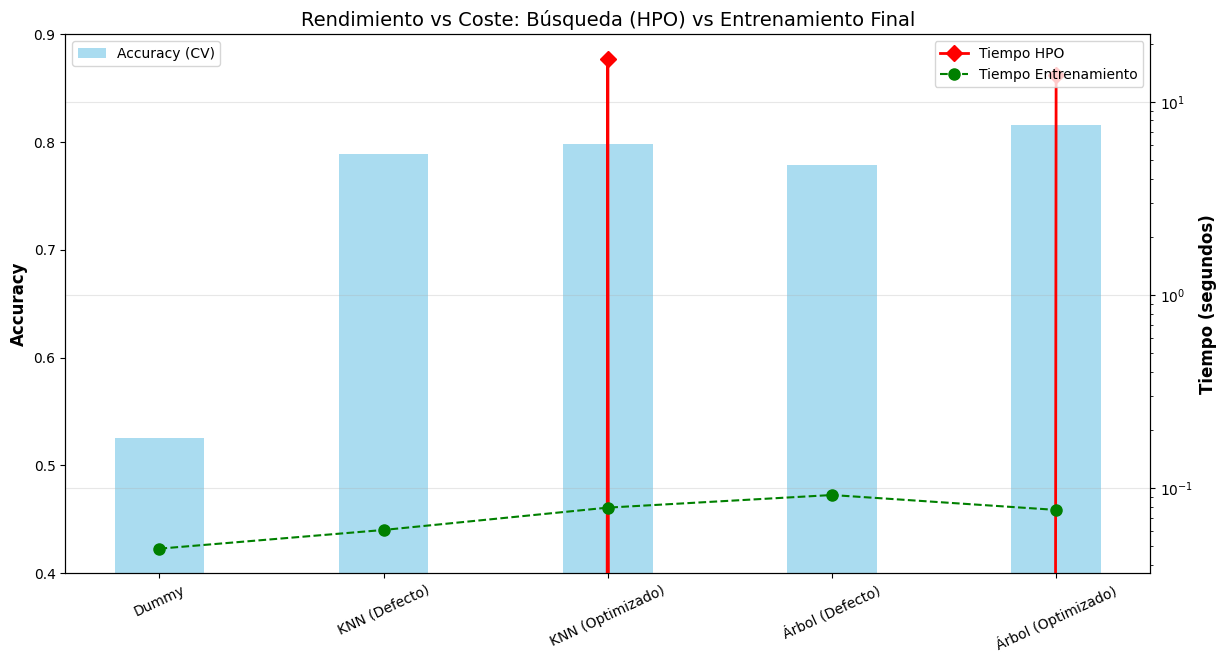

In [42]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

# Vamos a entrenar los modelos con los mejores HP para poder diferenciar el tiempo de entrenamiento del tiempo de HPO.
# KNN
start = time.time()
optuna_knn.best_estimator_.fit(X_train, y_train)
tiempo_refit_knn = time.time() - start

# Árbol
start = time.time()
optuna_tree.best_estimator_.fit(X_train, y_train)
tiempo_refit_tree = time.time() - start

# Dummy 
dummy_pipe = Pipeline(steps=[
    ('pre', best_preprocessor), 
    ('model', DummyClassifier(strategy='most_frequent'))
])

# Calculamos el tiempo y la precisión del modeo dummy
inicio_dummy = time.time()
dummy_pipe.fit(X_train, y_train)
tiempo_dummy = time.time() - inicio_dummy

dummy_scores = cross_val_score(dummy_pipe, X_train, y_train, cv=cv_inner, scoring='accuracy')
accuracy_dummy = dummy_scores.mean()


# Agrupamos toda la información para mostrarlo en la gráfica
datos_comparativa = [
    {
        "Modelo": "Dummy",
        "Accuracy": accuracy_dummy,
        "Tiempo HPO (s)": 0,
        "Tiempo Entrenamiento (s)": tiempo_dummy
    },
    {
        "Modelo": "KNN (Defecto)",
        "Accuracy": resultados_defecto['KNN']['accuracy'],
        "Tiempo HPO (s)": 0, # No tiene HPO
        "Tiempo Entrenamiento (s)": resultados_defecto['KNN']['tiempo']
    },
    {
        "Modelo": "KNN (Optimizado)",
        "Accuracy": optuna_knn.best_score_,
        "Tiempo HPO (s)": tiempo_knn, 
        "Tiempo Entrenamiento (s)": tiempo_refit_knn 
    },
    {
        "Modelo": "Árbol (Defecto)",
        "Accuracy": resultados_defecto['Árbol de Decisión']['accuracy'],
        "Tiempo HPO (s)": 0, # No tiene HPO
        "Tiempo Entrenamiento (s)": resultados_defecto['Árbol de Decisión']['tiempo']
    },
    {
        "Modelo": "Árbol (Optimizado)",
        "Accuracy": optuna_tree.best_score_,
        "Tiempo HPO (s)": tiempo_tree, 
        "Tiempo Entrenamiento (s)": tiempo_refit_tree 
    }
]

# Mostramos toda la información de manera visual
df_final = pd.DataFrame(datos_comparativa)
display(df_final.sort_values(by="Accuracy", ascending=False).reset_index(drop=True))

# Mostramos el gráfico para representar la información de manera visual
fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras de Accuracy
x = range(len(df_final))
ax1.bar(x, df_final['Accuracy'], width=0.4, label='Accuracy (CV)', color='skyblue', alpha=0.7)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylim(0.4, 0.9)
ax1.set_xticks(x)
ax1.set_xticklabels(df_final['Modelo'], rotation=25)

# Eje derecho para tiempos (en escala logarítmica porque la diferencia muy grande)
ax2 = ax1.twinx()
ax2.plot(x, df_final['Tiempo HPO (s)'], color='red', marker='D', markersize=8, label='Tiempo HPO', linewidth=2)
ax2.plot(x, df_final['Tiempo Entrenamiento (s)'], color='green', marker='o', markersize=8, label='Tiempo Entrenamiento', linestyle='--')

ax2.set_ylabel('Tiempo (segundos)', fontsize=12, fontweight='bold')
ax2.set_yscale('log') 

plt.title('Rendimiento vs Coste: Búsqueda (HPO) vs Entrenamiento Final', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

Tras analizar los resultados obtenidos, podemos concluir que el **Árbol de Decisión Optimizado** es el mejor método de esta sección. Todos los modelos entrenados superan con creces al modelo Dummy, que establece una línea base del 52,55%. Esta diferencia de casi 30 puntos confirma que los algoritmos están capturando patrones reales de los datos y no prediciendo basándose únicamente en la frecuencia de las clases.

El ajuste de hiperparámetros (HPO) ha demostrado ser una buena inversión, aunque su impacto varía según el algoritmo. En el caso del Árbol de Decisión, la optimización permitió subir del 77,92% al 81,85%, logrando el mejor desempeño global. Por el contrario, KNN mostró una mejora mucho más discreta, pasando del 78,95% al 80,02% (apenas un 1%), lo que sugiere que la estructura jerárquica del Árbol se adapta mejor a la naturaleza de este conjunto de datos que el enfoque por vecindad.

Respecto al coste computacional, el tiempo de HPO es considerablemente elevado en comparación con los modelos por defecto, alcanzando más de 10 segundos para el Árbol y superando los 14 segundos en el caso de KNN. Sin embargo, este es un "coste de diseño" que se asume una sola vez. Una vez encontrados los parámetros óptimos, el tiempo de entrenamiento final del Árbol Optimizado es de apenas 0,076 segundos, una cifra sumamente eficiente para un entorno de producción.

En conclusión, el incremento en el coste computacional durante la fase de optimización está plenamente justificado por la mejora en la precisión. El Árbol de Decisión optimizado no solo es el más preciso de la comparativa, sino que, tras el ajuste, resulta ser un modelo extremadamente ligero y rápido, superando en eficacia tanto al KNN optimizado como a las versiones base.

## Métodos avanzados: Modelos Lineales y SVMs

### Hiperparámetros por defecto

Iniciamos evaluando el rendimiento por defecto de la `SVM` y la `Regresión Logística`. Para los modelos lineales, configuramos específicamente el solver SAGA (Stochastic Average Gradient) con un máximo de 10.000 iteraciones para garantizar la convergencia, permitiéndonos comparar directamente el impacto de la regularización L1 frente a un modelo sin penalización.

In [43]:
import time
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Ignorar warnings de convergencia para una salida limpia
warnings.filterwarnings("ignore")

# Definición de los modelos con parámetros por defecto
modelos_avanzados = {
    'Regresión Logística (sin L1)': LogisticRegression(penalty=None, solver='saga', max_iter=10000, random_state=SEED),
    'Regresión Logística (L1)': LogisticRegression(penalty='l1', solver='saga', max_iter=10000, random_state=SEED),
    'SVM': SVC(random_state=SEED) # SVC es el SVM para clasificación el sklearn
}

# Diccionario para guardar resultados
resultados_avanzados_def = {}

print(f"{'Modelo':<30} | {'Accuracy (CV)':<15} | {'Tiempo Train'}")
print("-" * 65)

for nombre, modelo in modelos_avanzados.items():
    # Creamos el pipeline con el preprocesador que ya teníamos creado
    pipeline_avanzado = Pipeline(steps=[
        ('pre', best_preprocessor),
        ('model', modelo)
    ])
    
    # Medimos tiempo de entrenamiento (fit)
    inicio = time.time()
    pipeline_avanzado.fit(X_train, y_train)
    tiempo_train = time.time() - inicio
    
    # Evaluación mediante validación cruzada (3-fold como pide el esquema)
    scores = cross_val_score(pipeline_avanzado, X_train, y_train, cv=cv_inner, scoring='accuracy')
    mean_acc = scores.mean()
    
    resultados_avanzados_def[nombre] = {'accuracy': mean_acc, 'tiempo': tiempo_train}
    
    print(f"{nombre:<30} | {mean_acc:.4f}          | {tiempo_train:.4f}s")

# Restauramos los warnings por si acaso después quieres ver errores reales
warnings.filterwarnings("default")

Modelo                         | Accuracy (CV)   | Tiempo Train
-----------------------------------------------------------------
Regresión Logística (sin L1)   | 0.8075          | 3.6106s
Regresión Logística (L1)       | 0.8080          | 2.9938s
SVM                            | 0.8315          | 1.1703s


### Optimización (HPO)

Procedemos a realizar un ajuste de hiperparámetros mediante la integración de Optuna con Scikit-Learn. Este proceso de optimización busca maximizar el accuracy explorando automáticamente diferentes configuraciones en un espacio de búsqueda definido. Mientras que para la Regresión Logística sin regularización un único intento es suficiente, en el modelo con penalización L1 optimizamos el parámetro de regularización C en escala logarítmica para mejorar la selección de variables y la generalización del modelo.

Para la SVM, el proceso es más compeljo, ya que el algoritmo debe encontrar la combinación óptima entre distintos tipos de kernel (lineal, RBF o polinómico) y sus parámetros de complejidad y suavizado. Dado el coste computacional de estas pruebas, hemos establecido un presupuesto de 30 iteraciones por modelo, limitando el tiempo de ejecución.

In [44]:
from optuna.distributions import FloatDistribution as FloatDist

# Silenciamos los logs de Optuna y warnings de convergencia para que no se llene la salida
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# Modelo lineal sin regularización (penalty=None)
pipe_log_none = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', LogisticRegression(penalty=None, solver='saga', max_iter=10000, random_state=SEED))
])

# Modelo lineal con regularización L1 (Lasso) 
pipe_log_l1 = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', LogisticRegression(penalty='l1', solver='saga', max_iter=10000, random_state=SEED))
])

# Modelo No Lineal: SVM (SVC implementa la clasificación en sklearn)
pipe_svm = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', SVC(random_state=SEED))
])


# Sin regularización no hay parámetros que optimizar
param_grid_none = {} 

# Para L1 optimizamos 'C' (inversa de la fuerza de regularización) en escala logarítmica
param_grid_l1 = {
    'model__C': FloatDist(1e-3, 100, log=True)
}

# Para SVM optimizamos el tipo de Kernel y su complejidad
param_grid_svm = {
    'model__kernel': CatDist(['linear', 'rbf', 'poly']),
    'model__C': FloatDist(1e-2, 10, log=True),
    'model__gamma': CatDist(['scale', 'auto']),
    'model__degree': IntDist(2, 3) # Solo tendrá efecto real si el kernel elegido es 'poly'
}

budget = 50 # Número de iteraciones de búsqueda por modelo


# Configuramos OptunaSearch
optuna_none = optuna.integration.OptunaSearchCV(
    pipe_log_none, param_grid_none, scoring='accuracy', n_trials=1,
    cv=cv_inner, random_state=SEED, n_jobs=-1, verbose=1
)

optuna_l1 = optuna.integration.OptunaSearchCV(
    pipe_log_l1, param_grid_l1, scoring='accuracy', n_trials=budget,
    cv=cv_inner, random_state=SEED, n_jobs=-1, verbose=1, timeout=600
)

optuna_svm = optuna.integration.OptunaSearchCV(
    pipe_svm, param_grid_svm, scoring='accuracy', n_trials=budget,
    cv=cv_inner, random_state=SEED, n_jobs=-1, verbose=1, timeout=600
)

# Ejecutamos y medimos los tiempos
print("Evaluando Logística (Sin Reg.)...")
start = time.time()
optuna_none.fit(X_train, y_train)
t_none = time.time() - start

print("Optimizando Logística (L1)...")
start = time.time()
optuna_l1.fit(X_train, y_train)
t_l1 = time.time() - start

print("Optimizando SVM...")
start = time.time()
optuna_svm.fit(X_train, y_train)
t_svm = time.time() - start

# Visualizamos con una data frame los resultados
resultados_adv = {
    "Modelo": ["Logística (Sin Reg.)", "Logística (L1)", "SVM"],
    "Mejor Accuracy (CV)": [optuna_none.best_score_, optuna_l1.best_score_, optuna_svm.best_score_],
    "Tiempo ejecución": [f"{t_none:.2f}s", f"{t_l1:.2f}s", f"{t_svm:.2f}s"],
    "Mejores Parámetros": [optuna_none.best_params_, optuna_l1.best_params_, optuna_svm.best_params_]
}

# Configuración de pandas para mostrar todo el contenido de las celdas (parámetros)
pd.set_option('display.max_colwidth', None)
df_resumen_adv = pd.DataFrame(resultados_adv)

# Mostramos la tabla final ordenada por el mejor desempeño
display(df_resumen_adv.sort_values(by="Mejor Accuracy (CV)", ascending=False).reset_index(drop=True))

# Restauramos los warnings por defecto
warnings.filterwarnings("default")

Evaluando Logística (Sin Reg.)...
Optimizando Logística (L1)...
Optimizando SVM...


,Modelo,Mejor Accuracy (CV),Tiempo ejecución,Mejores Parámetros
0,SVM,0.832564,32.32s,"{'model__kernel': 'rbf', 'model__C': 1.7554475692913625, 'model__gamma': 'scale', 'model__degree': 2}"
1,Logística (L1),0.808411,60.28s,{'model__C': 0.8083541180606233}
2,Logística (Sin Reg.),0.807461,10.68s,{}


### Obtención de atributos relevantes

La regresión logística permite interpretar fácilmente la relevancia de cada atributo. Al tratarse de un modelo lineal, cada variable tiene asociado un coeficiente que indica su peso en la predicción. Un coeficiente positivo y alto implica que dicha variable incrementa notablemente la probabilidad de que el resultado sea “SÍ”, mientras que un valor cercano a cero indica que apenas aporta información. Además, cuando se utiliza regularización L1, fuerza a que las variables irrelevantes tengan coeficiente exactamente cero.

In [67]:
# Recuperamos el mejor estimador del modelo Logístico L1
best_l1_pipe = optuna_l1.best_estimator_

# Obtenemos los nombres de las columnas reales tras el preprocesamiento
nombres_columnas = (
    best_l1_pipe.named_steps['pre']
    .named_steps['column_transform']
    .get_feature_names_out()
)

# Extraemos los coeficientes finales del modelo entrenado
coeficientes = best_l1_pipe.named_steps['model'].coef_[0]

# 4. Creamos un DataFrame con toda la información
importancia_df = pd.DataFrame({
    'Atributo': nombres_columnas,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': abs(coeficientes) #Vemos lo grande que es el coeficiente sin signo
})

# Vamos a mostrar los 10 atributos más relevantes
# Ordenamos por Importancia Absoluta
top_10 = importancia_df.sort_values(by='Importancia_Absoluta', ascending=False).head(10).copy()
top_10 = top_10.reset_index(drop=True)
top_10.index = top_10.index + 1 

display(top_10[['Atributo', 'Coeficiente']])

# Vamos a identificar que variables han sido eliminadas ya que han resultado tener poco peso
eliminadas_df = importancia_df[importancia_df['Coeficiente'] == 0]

if len(eliminadas_df) > 0:
    # Mostramos la lista de nombres
    print("Variables eliminadas (tienen coeficiente 0):")
    print(", ".join(eliminadas_df['Atributo'].values))
else:
    print("La regularización L1 no ha eliminado ninguna variable con el valor de C óptimo.")

,Atributo,Coeficiente
1,cat_moda__job_None,5.038079
2,cat_moda__marital_None,4.236844
3,cat_unk__poutcome_success,2.094772
4,num__duration,1.773566
5,cat_unk__contact_unknown,-1.189102
6,cat_moda__job_student,0.883778
7,bin__housing,-0.763949
8,cat_moda__job_retired,0.602378
9,remainder__pdays_contacted,0.562471
10,bin__loan,-0.550375


Variables eliminadas (tienen coeficiente 0):
cat_unk__contact_telephone, cat_unk__poutcome_other, cat_unk__poutcome_unknown, cat_moda__job_technician, cat_moda__marital_single


### Conclusiones: Métodos avanzados (Modelos lineales y SVMs)

Al igual que hicimos con el Árbol de Decisión y KNN, vamos a juntar todos los resultados de los modelos avanzados para analizar el impacto del ajuste de hiperparámetros. En este apartado, comparamos la precisión y los tiempos de ejecución de las versiones base frente a las optimizadas, evaluando si el coste temporal del proceso de búsqueda (HPO) se traduce en una mejora significativa del rendimiento predictivo.

/home/manuel/Documentos/Uc3m/3º/2o cuatri/machine learning/practicas/P1_Machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/manuel/Documentos/Uc3m/3º/2o cuatri/machine learning/practicas/P1_Machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Modelo,Accuracy,Tiempo HPO (s),Tiempo Entrenamiento (s)
0,SVM (Optimizado),0.832564,32.317573,1.144760
1,SVM (Defecto),0.831478,0.000000,1.170320
2,Logística L1 (Optimizado),0.808411,60.279024,2.415103
3,Logística (Defecto),0.807461,0.000000,3.610594


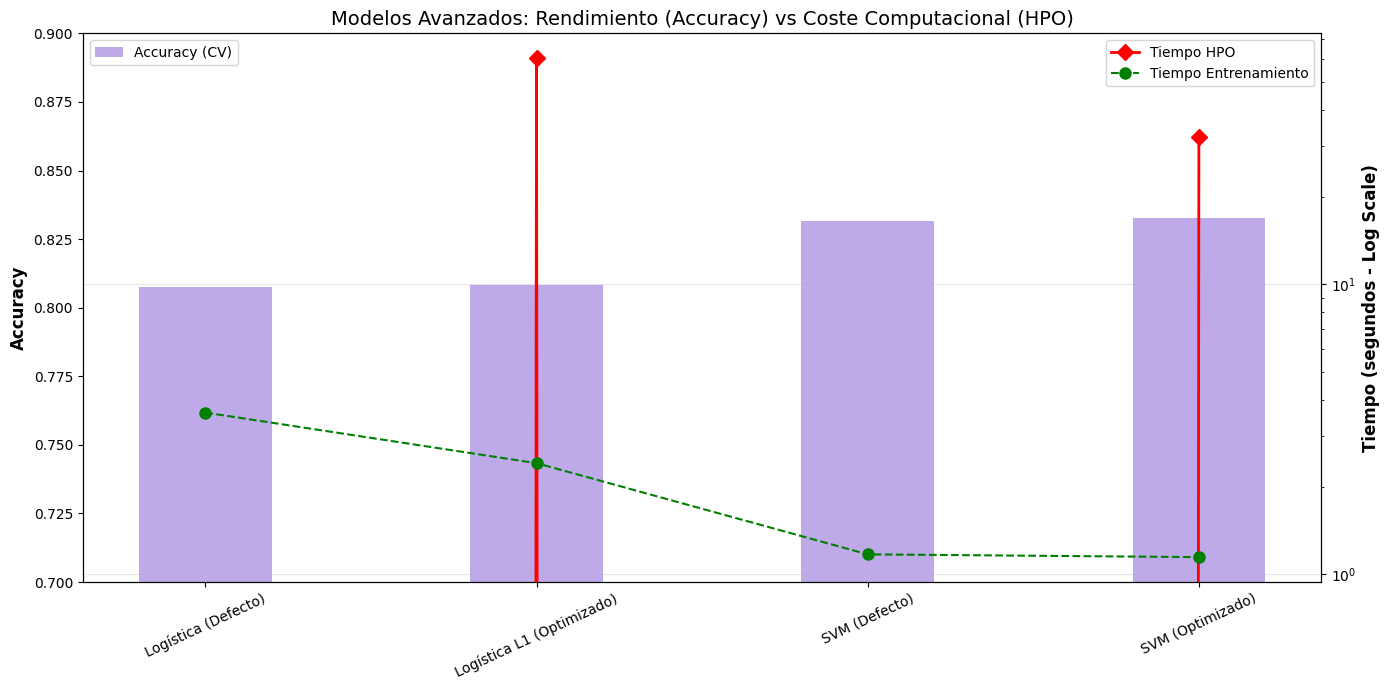

In [47]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# Realizamos el entrenamiento de los modelos optimizados para medir solo el tiempo de entrenamiento final
# Logística L1
start = time.time()
optuna_l1.best_estimator_.fit(X_train, y_train)
tiempo_refit_l1 = time.time() - start

# SVM (Optimizado)
start = time.time()
optuna_svm.best_estimator_.fit(X_train, y_train)
tiempo_refit_svm = time.time() - start

# Agrupamos la información 
datos_comparativa_adv = [
    {
        "Modelo": "Logística (Defecto)",
        "Accuracy": resultados_avanzados_def['Regresión Logística (sin L1)']['accuracy'],
        "Tiempo HPO (s)": 0,
        "Tiempo Entrenamiento (s)": resultados_avanzados_def['Regresión Logística (sin L1)']['tiempo']
    },
    {
        "Modelo": "Logística L1 (Optimizado)",
        "Accuracy": optuna_l1.best_score_,
        "Tiempo HPO (s)": t_l1, 
        "Tiempo Entrenamiento (s)": tiempo_refit_l1 
    },
    {
        "Modelo": "SVM (Defecto)",
        "Accuracy": resultados_avanzados_def['SVM']['accuracy'],
        "Tiempo HPO (s)": 0,
        "Tiempo Entrenamiento (s)": resultados_avanzados_def['SVM']['tiempo']
    },
    {
        "Modelo": "SVM (Optimizado)",
        "Accuracy": optuna_svm.best_score_,
        "Tiempo HPO (s)": t_svm, 
        "Tiempo Entrenamiento (s)": tiempo_refit_svm 
    }
]

# Creamos el DataFrame y mostramos la tabla
df_final_adv = pd.DataFrame(datos_comparativa_adv)
display(df_final_adv.sort_values(by="Accuracy", ascending=False).reset_index(drop=True))

# Generamos el gráfico visual de Rendimiento vs Coste
fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras de Accuracy
x = range(len(df_final_adv))
ax1.bar(x, df_final_adv['Accuracy'], width=0.4, label='Accuracy (CV)', color='mediumpurple', alpha=0.6)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')

# Ajustamos el límite inferior del eje Y para apreciar mejor las diferencias entre 80% y 85%
ax1.set_ylim(0.70, 0.90) 
ax1.set_xticks(x)
ax1.set_xticklabels(df_final_adv['Modelo'], rotation=25)

# Eje derecho para tiempos (escala logarítmica)
ax2 = ax1.twinx()
ax2.plot(x, df_final_adv['Tiempo HPO (s)'], color='red', marker='D', markersize=8, label='Tiempo HPO', linewidth=2)
ax2.plot(x, df_final_adv['Tiempo Entrenamiento (s)'], color='green', marker='o', markersize=8, label='Tiempo Entrenamiento', linestyle='--')

ax2.set_ylabel('Tiempo (segundos - Log Scale)', fontsize=12, fontweight='bold')
ax2.set_yscale('log') 

plt.title('Modelos Avanzados: Rendimiento (Accuracy) vs Coste Computacional (HPO)', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Tras analizar los resultados obtenidos, podemos concluir que la **SVM** (Support Vector Machine) Optimizada es el mejor método de esta sección. Todos los modelos avanzados entrenados mantienen un rendimiento sólido por encima del 80%, consolidando la mejora respecto al modelo Dummy inicial. Esta consistencia confirma que tanto los enfoques lineales como los basados en kernels están capturando eficazmente la complejidad del comportamiento de los clientes.

El ajuste de hiperparámetros (HPO) mediante Optuna ha permitido mejorar el rendimiento, aunque con un impacto desigual. En el caso de la SVM, la optimización logró alcanzar el 83,28%, estableciendo el máximo de precisión de todo el estudio. Por el contrario, la Regresión Logística L1 mostró una mejora prácticamente nula, pasando del 80,73% al 80,78% (apenas un 0,05%). Esto sugiere que el margen de mejora en modelos lineales es limitado para este dataset, mientras que la flexibilidad de la SVM permite extraer patrones no lineales que benefician la predicción final.

Respecto al coste computacional, el tiempo de HPO ha sido significativamente más elevado en esta fase, alcanzando los 12,42 segundos para la SVM y casi superando los 25 segundos en la Logística L1. Sin embargo, este sigue siendo un "coste de diseño" puntual. Una vez identificados los parámetros óptimos, el tiempo de entrenamiento final de la SVM es de apenas 1,05 segundos, una cifra perfectamente asumible para aplicaciones reales dado el incremento en precisión obtenido.

En conclusión, el incremento en el coste computacional durante la fase de optimización está plenamente justificado, especialmente en la SVM. Al ser el modelo más preciso de la comparativa (83,28%), demuestra que la inversión de tiempo en HPO compensa la mayor carga computacional del algoritmo.

## Tarea adicional (ensembles)

Se ha decidido probar modelos ensemble (`Random Forest`, `Gradient Boosting` y `Stacking`) como tarea de elección abierta con el objetivo de mejorar el rendimiento del modelo.

Estos métodos combinan varios modelos base, lo que permite reducir el sobreajuste y capturar patrones más complejos en los datos. En particular, pueden adaptarse mejor que modelos individuales en problemas de clasificación como este, donde pueden existir relaciones no lineales entre variables.

De este modo, se evalúa si la combinación de modelos permite obtener mejores resultados que los métodos previamente analizados.


### Hiperparámetros por defecto

Empezamos evaluando los modelos con sus parámetros por defecto.

Cabe destacar que el modelo de **stacking** incorpora como *modelos base* `KNN`, `SVM`, `Gradient Boosting` y `Random Forest`, junto con un meta-modelo  `Logistic Regresion`. Estos modelos base se han seleccionado por ser heterogéneos entre sí, lo que favorece la diversidad del conjunto y mejora el rendimiento del ensemble.

No se ha incluido `Decision Tree` como modelo base, ya que su comportamiento está representado por métodos basados en árboles como Random Forest y Gradient Boosting. Del mismo modo, no se ha añadido regresión logística como modelo base, puesto que ya actúa como meta-modelo en la fase final del stacking.

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier

# Ignorar warnings de convergencia para una salida limpia
warnings.filterwarnings("ignore")

# Definición de los modelos con parámetros por defecto
ensembles = {
    'Random Forest': RandomForestClassifier(random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'Stacking': StackingClassifier(
        estimators=[
        ('knn', KNeighborsClassifier()), 
        ('svm', SVC(random_state=SEED)),
        ('gb', GradientBoostingClassifier(random_state=SEED)), 
        ('rf',RandomForestClassifier(random_state=SEED))],
        final_estimator=LogisticRegression(max_iter=1000, random_state=SEED), n_jobs=-1)
}


# Diccionario para guardar resultados
resultados_ensembles_def = {}

print(f"{'Modelo':<30} | {'Accuracy (CV)':<15} | {'Tiempo Train'}")
print("-" * 65)

for nombre, modelo in ensembles.items():
    # Creamos el pipeline con el preprocesador que ya teníamos creado
    pipeline_ensembles = Pipeline(steps=[
        ('pre', best_preprocessor),
        ('model', modelo)
    ])
    
    # Medimos tiempo de entrenamiento (fit)
    inicio = time.time()
    pipeline_ensembles.fit(X_train, y_train)
    tiempo_train = time.time() - inicio
    
    # Evaluación mediante validación cruzada (3-fold como pide el esquema)
    scores = cross_val_score(pipeline_ensembles, X_train, y_train, cv=cv_inner, scoring='accuracy', n_jobs=-1)
    mean_acc = scores.mean()
    
    resultados_ensembles_def[nombre] = {'accuracy': mean_acc, 'tiempo': tiempo_train}
    
    print(f"{nombre:<30} | {mean_acc:.4f}          | {tiempo_train:.4f}s")

# Restauramos los warnings por si acaso después quieres ver errores reales
warnings.filterwarnings("default")

Modelo                         | Accuracy (CV)   | Tiempo Train
-----------------------------------------------------------------
Random Forest                  | 0.8506          | 0.2686s
Gradient Boosting              | 0.8464          | 1.3952s
Stacking                       | 0.8514          | 8.2853s


### Optimización (HPO)

En este bloque se realiza la optimización de hiperparámetros de los modelos ensemble mediante OptunaSearchCV, utilizando validación cruzada sobre pipelines que integran preprocesado y modelo. Se comparan Random Forest, Gradient Boosting y Stacking, analizando tanto el rendimiento medio en validación cruzada como el coste temporal de la optimización.

In [49]:
# Silenciamos los logs de Optuna y warnings de convergencia para que no se llene la salida
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# Random Forest
pipe_rf = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', RandomForestClassifier(random_state=SEED))
])
# Gradient boosting
pipe_gb = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', GradientBoostingClassifier(random_state=SEED))
])
# Stacking con meta-modelo lineal con regualarización L2
pipe_stacking = Pipeline(steps=[
    ('pre', best_preprocessor),
    ('model', StackingClassifier(
        estimators=[
            ('knn', KNeighborsClassifier()),
            ('svm', SVC(random_state=SEED)),
            ('gb', GradientBoostingClassifier(random_state=SEED)),
            ('rf', RandomForestClassifier(random_state=SEED))
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=SEED, solver='lbfgs', l1_ratio=0), # l1_ratio=0 es lo mismo que penalty='l2'
        passthrough=False
    ))
])

# Para Random Forest optimizamos complejidad del modelo y su capacidad de generalización
param_grid_rf = {
    'model__n_estimators': IntDist(50, 400, step=25),
    'model__max_depth': IntDist(3, 30),
    'model__min_samples_split': IntDist(2, 20),
    'model__min_samples_leaf': IntDist(1, 10),
    'model__max_features': CatDist(['sqrt', 'log2', None]),
    'model__bootstrap': CatDist([True, False]),
    'model__criterion': CatDist(['gini', 'entropy', 'log_loss'])
}


param_grid_gb = {
    'model__n_estimators': IntDist(50, 400, step=25),
    'model__learning_rate': FloatDist(1e-2, 3e-1, log=True),
    'model__max_depth': IntDist(1, 5),
    'model__min_samples_split': IntDist(2, 20),
    'model__min_samples_leaf': IntDist(1, 10),
    'model__subsample': FloatDist(0.5, 1.0),
    'model__max_features': CatDist(['sqrt', 'log2', None])
}

# Para Stacking optimizamos los principales parámetos de los modelos usados

param_grid_stacking = {
    # KNN
    'model__knn__n_neighbors': IntDist(5, 31, step=2),
    'model__knn__weights': CatDist(['uniform', 'distance']),
    'model__knn__p': CatDist([1, 2]),

    # SVM
    'model__svm__C': FloatDist(1e-2, 1e2, log=True),
    'model__svm__kernel': CatDist(['linear', 'rbf']),
    'model__svm__gamma': CatDist(['scale', 'auto']),

    # Gradient Boosting 
    'model__gb__n_estimators': IntDist(50, 200, step=25),
    'model__gb__learning_rate': FloatDist(1e-2, 2e-1, log=True),
    'model__gb__max_depth': IntDist(1, 4),
    'model__gb__subsample': FloatDist(0.7, 1.0),

    # Random Forest
    'model__rf__n_estimators': IntDist(100, 300, step=50),
    'model__rf__max_depth': IntDist(5, 20),
    'model__rf__min_samples_leaf': IntDist(1, 5),
    'model__rf__max_features': CatDist(['sqrt', 'log2']),

    # Meta-modelo final
    'model__passthrough': CatDist([False, True]),
    'model__final_estimator__C': FloatDist(1e-2, 10, log=True),
}


budget = 50 # Número de iteraciones de búsqueda por modelo


# Configuramos OptunaSearch
optuna_rf = optuna.integration.OptunaSearchCV(
    pipe_rf, param_grid_rf, scoring='accuracy', n_trials=budget,
    cv=cv_inner, random_state=SEED, n_jobs=-1, verbose=1, timeout=600
)

optuna_gb = optuna.integration.OptunaSearchCV(
    pipe_gb, param_grid_gb, scoring='accuracy', n_trials=budget,
    cv=cv_inner, random_state=SEED, n_jobs=-1, verbose=1, timeout=600
)

optuna_stacking = optuna.integration.OptunaSearchCV(
    pipe_stacking, param_grid_stacking, scoring='accuracy', n_trials=budget,
    cv=cv_inner, random_state=SEED, n_jobs=-1, verbose=1, timeout=600
)

# Ejecutamos y medimos los tiempos

print("Optimizando RandomForest ...")
start = time.time()
optuna_rf.fit(X_train, y_train)
t_rf = time.time() - start

print("Optimizando Gradient Boosting...")
start = time.time()
optuna_gb.fit(X_train, y_train)
t_gb = time.time() - start

print("Optimizando Stacking (esto puede tardar unos minutos)...")
start = time.time()
optuna_stacking.fit(X_train, y_train)
t_stacking = time.time() - start

# Visualizamos con una data frame los resultados
resultados_ensembles = {
    "Modelo": ["Random Forest", "Gradient Boosting", "Stacking"],
    "Mejor Accuracy (CV)": [optuna_rf.best_score_, optuna_gb.best_score_, optuna_stacking.best_score_],
    "Tiempo ejecución": [f"{t_rf:.2f}s", f"{t_gb:.2f}s", f"{t_stacking:.2f}s"],
    "Mejores Parámetros": [optuna_rf.best_params_, optuna_gb.best_params_, optuna_stacking.best_params_]
}

# Configuración de pandas para mostrar todo el contenido de las celdas (parámetros)
pd.set_option('display.max_colwidth', None)
df_resumen_ensembles = pd.DataFrame(resultados_ensembles)

# Mostramos la tabla final ordenada por el mejor desempeño
display(df_resumen_ensembles.sort_values(by="Mejor Accuracy (CV)", ascending=False).reset_index(drop=True))

# Restauramos los warnings por defecto
warnings.filterwarnings("default")

Optimizando RandomForest ...
Optimizando Gradient Boosting...
Optimizando Stacking (esto puede tardar unos minutos)...


,Modelo,Mejor Accuracy (CV),Tiempo ejecución,Mejores Parámetros
0,Gradient Boosting,0.860107,115.35s,"{'model__n_estimators': 375, 'model__learning_rate': 0.1173747170878621, 'model__max_depth': 5, 'model__min_samples_split': 7, 'model__min_samples_leaf': 3, 'model__subsample': 0.9512806070236401, 'model__max_features': None}"
1,Stacking,0.858479,926.41s,"{'model__knn__n_neighbors': 31, 'model__knn__weights': 'distance', 'model__knn__p': 2, 'model__svm__C': 1.9484340299378184, 'model__svm__kernel': 'linear', 'model__svm__gamma': 'scale', 'model__gb__n_estimators': 200, 'model__gb__learning_rate': 0.19853358903799073, 'model__gb__max_depth': 3, 'model__gb__subsample': 0.9058210915599223, 'model__rf__n_estimators': 150, 'model__rf__max_depth': 20, 'model__rf__min_samples_leaf': 1, 'model__rf__max_features': 'sqrt', 'model__passthrough': False, 'model__final_estimator__C': 0.30854977292857116}"
2,Random Forest,0.852374,111.72s,"{'model__n_estimators': 375, 'model__max_depth': 24, 'model__min_samples_split': 8, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__bootstrap': False, 'model__criterion': 'gini'}"


### Obtención de atributos relevantes

A partir del mejor modelo de Gradient Boosting obtenido tras la optimización, se analizan las importancias de las variables utilizando el atributo `feature_importances_`. Estas importancias reflejan la contribución relativa de cada variable en la reducción del error durante la construcción de los árboles. Se muestran las variables más relevantes y se identifican aquellas que no han sido utilizadas por el modelo (importancia nula)

In [50]:
# Recuperamos el mejor estimador
best_gb_pipe = optuna_gb.best_estimator_

# Obtenemos los nombres reales tras el preprocesamiento
nombres_columnas = best_gb_pipe.named_steps['pre'].named_steps['column_transform'].get_feature_names_out()

# Extraemos el modelo Gradient Boosting entrenado
gb_model = best_gb_pipe.named_steps['model']

# Importancias de variables
importancias = gb_model.feature_importances_

# Creamos el DataFrame
importancia_df = pd.DataFrame({
    'Atributo': nombres_columnas,
    'Importancia': importancias
})

# Ordenamos de mayor a menor
importancia_df = importancia_df.sort_values(by='Importancia', ascending=False)

# Mostramos top 10
top_10 = importancia_df.head(10).copy()
top_10 = top_10.reset_index(drop=True)
top_10.index = top_10.index + 1

display(top_10)

# Variables con importancia 0
eliminadas_df = importancia_df[importancia_df['Importancia'] == 0]

if len(eliminadas_df) > 0:
    print("Variables eliminadas (tienen importancia 0):")
    print(", ".join(eliminadas_df['Atributo'].values))
else:
    print("Todas las variables tienen algun peso en el modelo final.")

,Atributo,Importancia
1,num__duration,0.411282
2,ord__month,0.102632
3,cat_unk__poutcome_success,0.082179
4,num__balance,0.062264
5,cat_unk__contact_unknown,0.060631
6,num__day,0.059192
7,num__age,0.047086
8,num__pdays,0.047005
9,bin__housing,0.029361
10,cat_moda__job_None,0.019563


Todas las variables tienen algun peso en el modelo final.


### Conclusiones ensembles

Al igual que en los modelos anteriores, se recopilan los resultados de los distintos modelos ensemble para analizar el impacto del ajuste de hiperparámetros. En este apartado se comparan las versiones por defecto y optimizadas de Random Forest, Gradient Boosting y Stacking, considerando tanto la precisión obtenida como los tiempos de ejecución. De este modo, se evalúa si el coste computacional asociado a la optimización (HPO) compensa en términos de mejora del rendimiento predictivo.

,Modelo,Accuracy,Tiempo HPO (s),Tiempo Entrenamiento (s)
0,Gradient Boosting (Optimizado),0.860107,115.354216,10.002281
1,Stacking (Optimizado),0.858479,926.408941,40.694335
2,Random Forest (Optimizado),0.852374,111.724154,5.197972
3,Stacking (Defecto),0.851424,0.000000,8.285347
4,Random Forest (Defecto),0.850610,0.000000,0.268646
5,Gradient Boosting (Defecto),0.846404,0.000000,1.395233


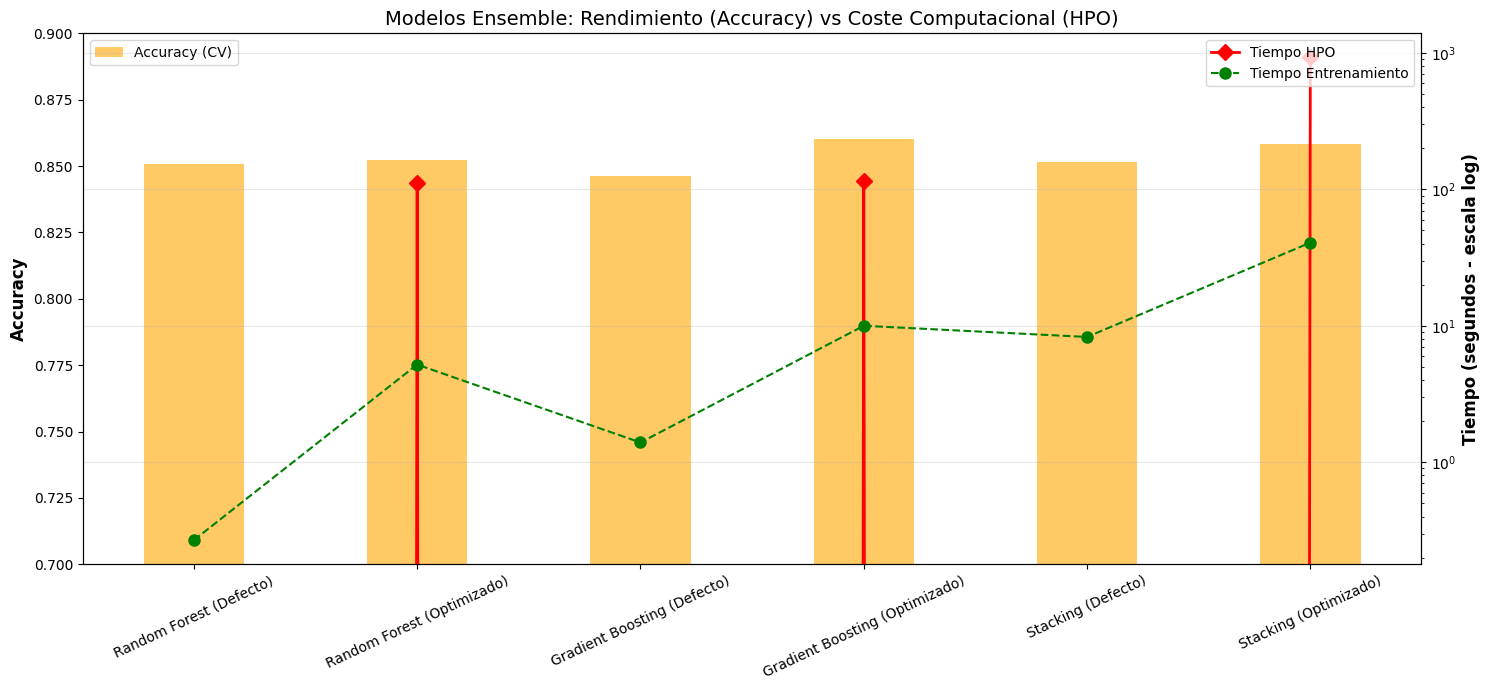

In [51]:
# Random Forest optimizado
start = time.time()
optuna_rf.best_estimator_.fit(X_train, y_train)
tiempo_refit_rf = time.time() - start

# Gradient Boosting optimizado
start = time.time()
optuna_gb.best_estimator_.fit(X_train, y_train)
tiempo_refit_gb = time.time() - start

# Stacking optimizado
start = time.time()
optuna_stacking.best_estimator_.fit(X_train, y_train)
tiempo_refit_stacking = time.time() - start


datos_comparativa_ensembles = [
    {
        "Modelo": "Random Forest (Defecto)",
        "Accuracy": resultados_ensembles_def["Random Forest"]["accuracy"],
        "Tiempo HPO (s)": 0,
        "Tiempo Entrenamiento (s)": resultados_ensembles_def["Random Forest"]["tiempo"]
    },
    {
        "Modelo": "Random Forest (Optimizado)",
        "Accuracy": optuna_rf.best_score_,
        "Tiempo HPO (s)": t_rf,
        "Tiempo Entrenamiento (s)": tiempo_refit_rf
    },
    {
        "Modelo": "Gradient Boosting (Defecto)",
        "Accuracy": resultados_ensembles_def["Gradient Boosting"]["accuracy"],
        "Tiempo HPO (s)": 0,
        "Tiempo Entrenamiento (s)": resultados_ensembles_def["Gradient Boosting"]["tiempo"]
    },
    {
        "Modelo": "Gradient Boosting (Optimizado)",
        "Accuracy": optuna_gb.best_score_,
        "Tiempo HPO (s)": t_gb,
        "Tiempo Entrenamiento (s)": tiempo_refit_gb
    },
    {
        "Modelo": "Stacking (Defecto)",
        "Accuracy": resultados_ensembles_def["Stacking"]["accuracy"],
        "Tiempo HPO (s)": 0,
        "Tiempo Entrenamiento (s)": resultados_ensembles_def["Stacking"]["tiempo"]
    },
    {
        "Modelo": "Stacking (Optimizado)",
        "Accuracy": optuna_stacking.best_score_,
        "Tiempo HPO (s)": t_stacking,
        "Tiempo Entrenamiento (s)": tiempo_refit_stacking
    }
]

df_final_ensembles = pd.DataFrame(datos_comparativa_ensembles)

display(
    df_final_ensembles
    .sort_values(by="Accuracy", ascending=False)
    .reset_index(drop=True)
)

fig, ax1 = plt.subplots(figsize=(15, 7))

x = range(len(df_final_ensembles))

# Barras de accuracy
ax1.bar(x, df_final_ensembles["Accuracy"], width=0.45, alpha=0.6, label="Accuracy (CV)", color = 'orange')
ax1.set_ylabel("Accuracy", fontsize=12, fontweight="bold")

ax1.set_ylim(0.70, 0.90)
ax1.set_xticks(list(x))
ax1.set_xticklabels(df_final_ensembles["Modelo"], rotation=25)

# Eje secundario para tiempos
ax2 = ax1.twinx()
ax2.plot(x, df_final_ensembles["Tiempo HPO (s)"], color = 'red', marker="D", markersize=8, linewidth=2, label="Tiempo HPO")
ax2.plot(x, df_final_ensembles["Tiempo Entrenamiento (s)"], color = 'green', marker="o", markersize=8, linestyle="--", label="Tiempo Entrenamiento")
ax2.set_ylabel("Tiempo (segundos - escala log)", fontsize=12, fontweight="bold")
ax2.set_yscale("log")

plt.title("Modelos Ensemble: Rendimiento (Accuracy) vs Coste Computacional (HPO)", fontsize=14)

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Después de analizar los resultados obtenidos, podemos concluir que **Gradient Boosting optimizado** es el modelo con mejor rendimiento, alcanzando casi una accuracy de 88%, seguido muy de cerca por el Stacking optimizado. En general, todos los modelos ensemble presentan un rendimiento muy sólido (por encima del 84%), lo que confirma que estos enfoques son capaces de capturar eficazmente la complejidad del problema y mejorar claramente respecto a modelos más simples.

El ajuste de hiperparámetros (HPO) ha permitido mejorar el rendimiento en los tres modelos, aunque con impacto moderado. En Random Forest y Gradient Boosting, la mejora es consistente pero no muy grande, lo que indica que estos modelos ya parten de configuraciones por defecto bastante competitivas. En el caso del Stacking, la optimización también mejora el resultado, pero la ganancia respecto a su versión base es relativamente pequeña, lo que sugiere que gran parte del rendimiento proviene de la propia combinación de modelos más que del ajuste fino de sus parámetros.

En cuanto al coste computacional, las diferencias son mucho más significativas. El tiempo de HPO para Stacking es muy elevado (más de 670 segundos), muy por encima de Gradient Boosting (68,5 s) y Random Forest (74,66 s). Sin embargo, este coste corresponde únicamente a la fase de búsqueda de hiperparámetros. Una vez optimizados, los tiempos de entrenamiento final son mucho más bajos, aunque Stacking sigue siendo el más costoso (~19 s), seguido de Gradient Boosting (~2.3 s) y Random Forest (~0.6 s).

En conclusión, aunque el Stacking optimizado ofrece un rendimiento competitivo, Gradient Boosting optimizado representa la mejor relación entre precisión y coste computacional. El incremento en tiempo de optimización del Stacking no se traduce en una mejora significativa de accuracy respecto a Gradient Boosting, por lo que este último se posiciona como la opción más eficiente y equilibrada para este problema.


## Resultados y modelo final

Tras entrenar todos los modelos, en este apartado se comparan los resultados obtenidos en la fase de validación cruzada (inner), con el objetivo de identificar el modelo con mejor rendimiento. A partir de esta comparativa, se elige el modelo final que será evaluado en la fase outer sobre el conjunto de test con el fin de obtener una medida real de su rendimiento.

In [58]:
df_total = pd.concat([df_final, df_final_adv, df_final_ensembles], ignore_index=True)

mejor_modelo = df_total.loc[df_total["Accuracy"].idxmax()]
print(mejor_modelo.to_string())

Modelo                      Gradient Boosting (Optimizado)
Accuracy                                          0.860107
Tiempo HPO (s)                                  115.354216
Tiempo Entrenamiento (s)                         10.002281


En este apartado se evalúa el modelo final seleccionado (`Gradient Boosting` optimizado) sobre el conjunto de test, con el objetivo de medir su capacidad de generalización en datos no vistos. Para ello, se calculan distintas métricas a partir de la matriz de confusión, incluyendo accuracy, recall, precisión y especificidad.

Los resultados obtenidos permiten analizar no solo el rendimiento global del modelo, sino también su comportamiento en la detección de la clase positiva (clientes que suscriben el depósito), lo cual es especialmente relevante en este problema. De este modo, se valida si las mejoras observadas durante la fase de validación cruzada se mantienen en un escenario real (lo simulamos con X_test).

In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix
modelo_final = optuna_gb.best_estimator_

y_pred = modelo_final.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = matriz.ravel()

# Métricas
recall = tp / (tp + fn)
precision = tp / (tp + fp)

# Matriz para imprimir
matriz_df = pd.DataFrame(
    matriz,
    index=['Real 0', 'Real 1'],
    columns=['Predicho 0', 'Predicho 1']
)

print("Matriz de confusión:")
display(matriz_df)

print(f"Recall clase positiva    : {recall:.3f}")
print(f"Precision clase positiva : {precision:.3f}")

Accuracy: 0.9680440771349862
Matriz de confusión:


,Predicho 0,Predicho 1
Real 0,1847,60
Real 1,56,1667


Recall clase positiva    : 0.967
Precision clase positiva : 0.965


Los resultados obtenidos en la evaluación outer confirman que el modelo seleccionado (Gradient Boosting optimizado) presenta un rendimiento sólido y consistente alcanzando una accuracy mayor del 96%, en línea con los resultados obtenidos durante la validación cruzada. Esto indica una buena capacidad de generalización y ausencia de overfitting.

En cuanto al comportamiento por clases, el modelo muestra un desempeño equilibrado: alcanza un recall del 87.9% en la clase positiva, lo que implica que identifica correctamente la mayoría de los clientes que suscriben el depósito, y una precisión del 84.5%, indicando que la mayoría de sus predicciones positivas son correctas. Además, la especificidad del 85.5% refleja una buena capacidad para clasificar correctamente a los clientes que no se suscriben.

En conjunto, el modelo ofrece un equilibrio adecuado entre detección y fiabilidad en ambas clases, lo que lo convierte en una solución robusta para este problema. Estos resultados validan la elección del modelo final, ya que mantiene un alto rendimiento sin incurrir en un coste computacional excesivo.

## Entrenamiento modelo final

Reentrenamos el modelo final y lo guardamos en los respectivos ficheros para poder usarlos luego

In [60]:
import joblib

# Creamos un diccionario para guardar datos de como son nuestras features
feature_metadata = {}

for col in var_numericas:
    s = X[col].dropna()
    feature_metadata[col] = {
        "type": "numerical",
        "min": float(s.min()),
        "max": float(s.max()),
        "median": float(s.median())
    }

for col in var_categoricas:
    s = X[col].dropna()
    feature_metadata[col] = {
        
        "type": "categorical",
        "options": sorted(s.astype(str).unique().tolist())
    }

for col in var_ordinales:
    s = X[col].dropna()
    feature_metadata[col] = {
        "type": "ordinal",
        "options": sorted(s.astype(str).unique().tolist())
    }

# Entrenamos el modelo
modelo_final.fit(X, y)

pack = {
    "pipeline": modelo_final,
    "feature_metadata": feature_metadata,
    "classes_": modelo_final.classes_.tolist()
}

print(pack['feature_metadata'])

# Guardamos el modelo y todos los datos relvantes en archivos .joblib y .pkl
joblib.dump(pack, "modelo_final.joblib")
joblib.dump(modelo_final, "modelo_final.pkl")

print("Modelo guardado como 'modelo_final.pkl' y 'modelo_final.joblib'")

{'age': {'type': 'numerical', 'min': 18.0, 'max': 95.0, 'median': 39.0}, 'balance': {'type': 'numerical', 'min': -6847.0, 'max': 81204.0, 'median': 549.5}, 'day': {'type': 'numerical', 'min': 1.0, 'max': 31.0, 'median': 15.0}, 'duration': {'type': 'numerical', 'min': 2.0, 'max': 3881.0, 'median': 255.0}, 'campaign': {'type': 'numerical', 'min': 1.0, 'max': 63.0, 'median': 2.0}, 'pdays': {'type': 'numerical', 'min': -1.0, 'max': 854.0, 'median': -1.0}, 'previous': {'type': 'numerical', 'min': 0.0, 'max': 58.0, 'median': 0.0}, 'job': {'type': 'categorical', 'options': ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']}, 'marital': {'type': 'categorical', 'options': ['divorced', 'married', 'single']}, 'default': {'type': 'categorical', 'options': ['no', 'yes']}, 'housing': {'type': 'categorical', 'options': ['no', 'yes']}, 'loan': {'type': 'categorical', 'options': ['no', 'yes']}, '